# Explore sequential Markovian ABC

In [1]:
import sys
sys.path.append('/home/cristobal/TB/projects/IS_simulation')

import abc_sampler
import niche_model
from ete3 import Tree

Load and sample priors

In [2]:
priors = abc_sampler.load_priors("../abc_priors.yaml")
tree = Tree("../data/subsampled_tree.rooted.nex", format=1)

In [3]:
import pandas as pd

metadata_path = "../data/metadata_reduced.tsv"

# Create lineage index
metadata = pd.read_csv(metadata_path, sep='\t')
lineage_map = dict(zip(metadata['GNUMBER'], metadata['LINEAGE_x']))

# Drop keys that are not in the tree
tip_names = sorted(tree.get_leaf_names())
lineage_map = {k: v for k, v in lineage_map.items() if k in tip_names}

In [4]:
particle = abc_sampler.sample_priors(priors)
particle

{'p_neutral': 0.2366567518181315,
 'gamma_shape': 1.7680201193288898,
 'gamma_scale': 0.6981429375170832,
 'r_birth': np.float64(4.438163415607394e-05),
 'r_loss': np.float64(0.00016685160491422476)}

Run simulation a single simulation

In [18]:
L = 7360

args = [
    1,
    particle, 
    tree, 
    L,
    tip_names,
    lineage_map,
    1
]
    
tip_results = abc_sampler.run_one_particle_smc(args)

tip_results

(1,
 {'p_neutral': 0.368472671542369,
  'gamma_shape': 1.8532316903268118,
  'gamma_scale': 0.3331582602839243,
  'r_birth': np.float64(6.850594430071586e-05),
  'r_loss': np.float64(0.00017295646186112377)},
 {'total_cn': 3694.0,
  'mean_cn': 7.44758064516129,
  'std_cn': 10.465975377361817,
  'min_cn': 1.0,
  'q25_cn': 1.0,
  'median_cn': 3.0,
  'q75_cn': 8.0,
  'max_cn': 43.0,
  'lineage_var': 118.21486175115207,
  'lineage_sd': 10.87266580702047,
  'n_occupied_sites': 761,
  'occupied_fraction': np.float64(0.10339673913043479),
  'n_empty_sites': 6599,
  'gini_occupancy': 0.9715993620677479,
  'n_sites_freq_05': 33,
  'n_sites_freq_10': 24,
  'max_occupancy': 496,
  'mean_occupancy': 0.5019021739130435,
  'sfs_1': np.float64(0.6386333771353482),
  'sfs_2': np.float64(0.1392904073587385),
  'sfs_3': np.float64(0.07227332457293036),
  'sfs_4': np.float64(0.03153745072273324),
  'sfs_5': np.float64(0.018396846254927726),
  'sfs_6_10': np.float64(0.03153745072273324),
  'sfs_11_5pct': 

## Get observed stats

In [10]:
from lib import get_observed_stats

DEFAULT_MATRIX = '/home/cristobal/TB/projects/MTBC_IS6110-poly/workflow/results/detettore/ALL_presence-absence.5prime.tsv'
DEFAULT_MATRIX_META = '/home/cristobal/TB/projects/MTBC_IS6110-poly/workflow/results/detettore/ALL_presence-absence.metadata.tsv'

matrix = pd.read_csv(DEFAULT_MATRIX, sep='\t', index_col=0)
matrix_meta = pd.read_csv(DEFAULT_MATRIX_META, sep='\t')

In [11]:
# Remove strains that are not in the tree
if tip_names is not None:
    matrix = matrix.loc[matrix.index.isin(tip_names)]
# Remove columns that sum to zero
matrix = matrix.loc[:, (matrix.sum(axis=0) > 0)]

In [12]:
tip_results_obs = get_observed_stats.aggregate_sites_to_tip_results(matrix, matrix_meta, tip_names=tip_names, side=5)

Summary stats without considering empty sites

In [16]:
obs_stats = niche_model.get_summary_stats(tip_results_obs, tip_names, lineage_map)
obs_stats

{'total_cn': 5502.0,
 'mean_cn': 11.09274193548387,
 'std_cn': 7.668344199997272,
 'min_cn': 0.0,
 'q25_cn': 4.0,
 'median_cn': 11.0,
 'q75_cn': 16.0,
 'max_cn': 31.0,
 'lineage_var': 56.83140701650067,
 'lineage_sd': 7.538660823813515,
 'n_occupied_sites': 439,
 'occupied_fraction': np.float64(1.0),
 'n_empty_sites': 0,
 'gini_occupancy': 0.7550776731426716,
 'n_sites_freq_05': 56,
 'n_sites_freq_10': 45,
 'max_occupancy': 399,
 'mean_occupancy': 12.533029612756264,
 'sfs_1': np.float64(0.3712984054669704),
 'sfs_2': np.float64(0.14578587699316628),
 'sfs_3': np.float64(0.08656036446469248),
 'sfs_4': np.float64(0.0387243735763098),
 'sfs_5': np.float64(0.04555808656036447),
 'sfs_6_10': np.float64(0.10933940774487472),
 'sfs_11_5pct': np.float64(0.07517084282460136),
 'sfs_5_10pct': np.float64(0.025056947608200455),
 'sfs_10_25pct': np.float64(0.09339407744874716),
 'sfs_gt25pct': np.float64(0.009111617312072893)}

Summary stats considering empty sites

In [ ]:
n_empty = 7360 - len(tip_results_obs['G00883'])
tip_results_obs_empty = get_observed_stats.add_empty_sites(tip_results_obs, n_empty)

obs_stats_empty = niche_model.get_summary_stats(tip_results_obs_empty, tip_names, lineage_map)
obs_stats_empty

In [ ]:
import yaml

with open("obs_stats_empty.yaml", "w") as f:
    yaml.dump(obs_stats_empty, f, sort_keys=False)

# Prior-predictive sweep

In [20]:
tags = []
cn_cap = 10000

for _ in range(100):
    particle = abc_sampler.sample_priors(priors)
    tip_results = niche_model.run_simulation(tree=tree, L=L, seed=None, **particle)
    cn = sum(v.sum() for v in tip_results.values())
    tags.append({**particle, 'total_cn': cn,
                 'extinct': cn == 0, 'exploded': cn > cn_cap})

In [21]:
tags

[{'p_neutral': 0.1652150992544838,
  'gamma_shape': 0.7872455888204977,
  'gamma_scale': 0.33882093310634864,
  'r_birth': np.float64(0.00015756506001005042),
  'r_loss': np.float64(0.0014142933851782169),
  'total_cn': np.int64(0),
  'extinct': np.True_,
  'exploded': np.False_},
 {'p_neutral': 0.41269271178790484,
  'gamma_shape': 1.2593084117798579,
  'gamma_scale': 0.7950327754795558,
  'r_birth': np.float64(0.00021108017832597697),
  'r_loss': np.float64(0.001803567846354026),
  'total_cn': np.int64(0),
  'extinct': np.True_,
  'exploded': np.False_},
 {'p_neutral': 0.14195113891096306,
  'gamma_shape': 0.7913872526978287,
  'gamma_scale': 0.7553705908841871,
  'r_birth': np.float64(3.307006573587281e-05),
  'r_loss': np.float64(0.0008093345265081562),
  'total_cn': np.int64(140),
  'extinct': np.False_,
  'exploded': np.False_},
 {'p_neutral': 0.22036809929851825,
  'gamma_shape': 1.2389400277090263,
  'gamma_scale': 0.6638974387287832,
  'r_birth': np.float64(0.00014934603198408

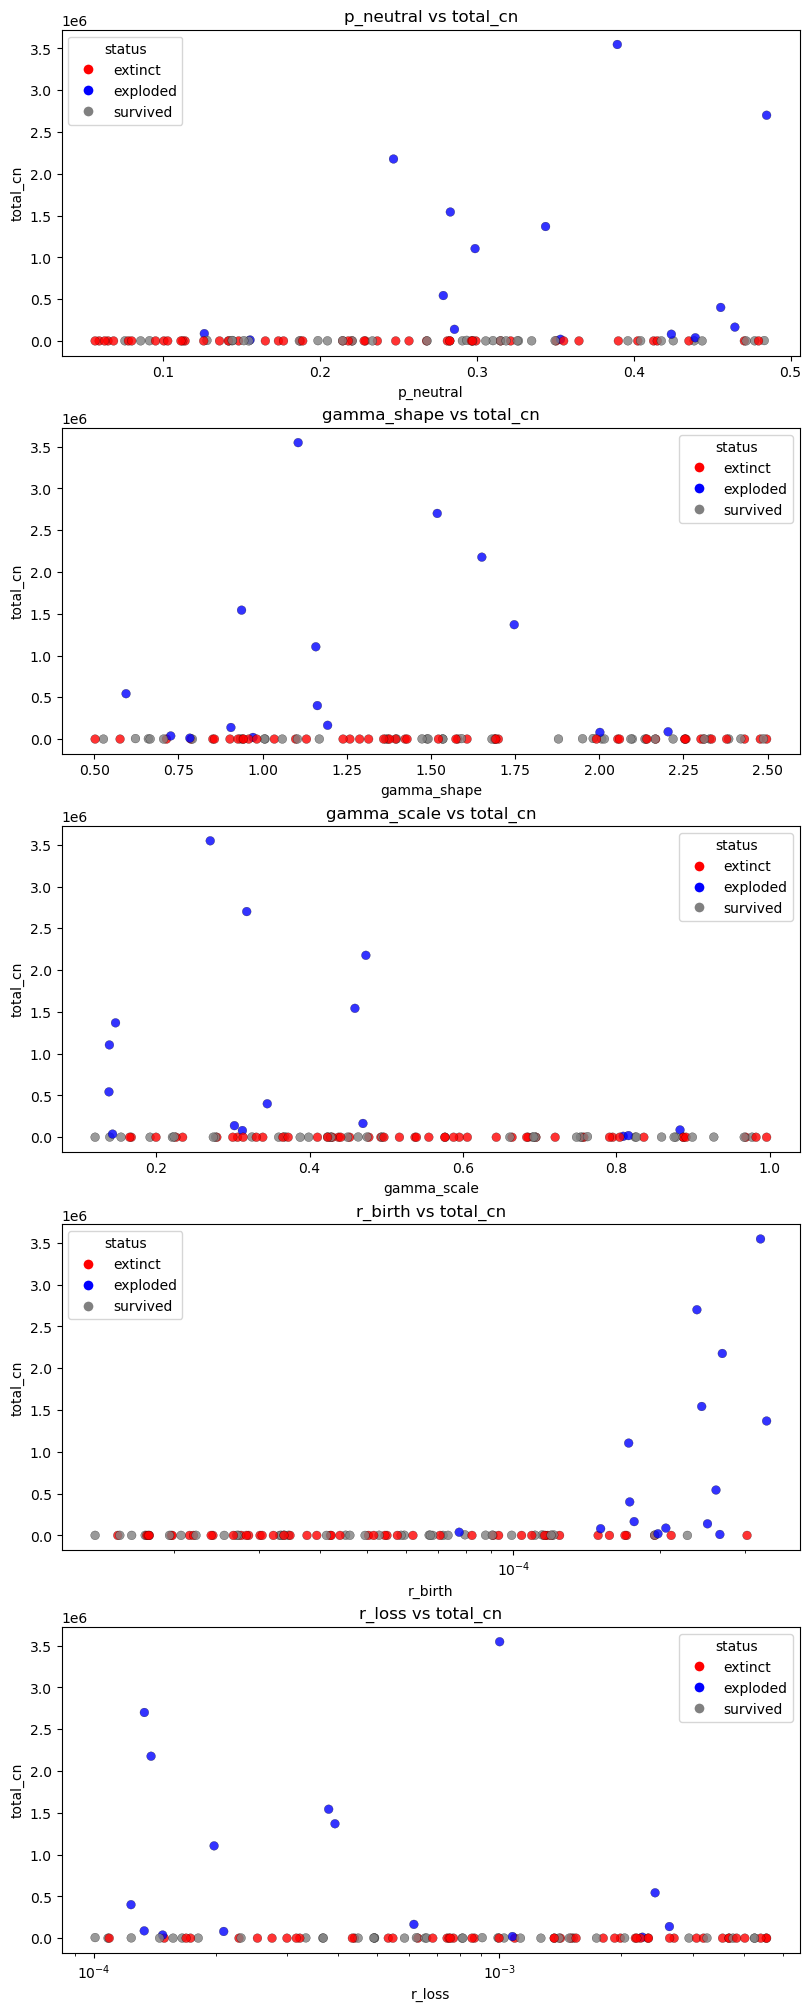

In [22]:
import pandas as pd

import matplotlib.pyplot as plt

df = pd.DataFrame(tags)
df['status'] = df.apply(
    lambda row: 'extinct' if row['extinct'] else ('exploded' if row['exploded'] else 'survived'),
    axis=1
)

params = ['p_neutral', 'gamma_shape', 'gamma_scale', 'r_birth', 'r_loss']
colors = {'extinct': 'red', 'exploded': 'blue', 'survived': 'gray'}

fig, axes = plt.subplots(len(params), 1, figsize=(8, 4 * len(params)), constrained_layout=True)

for ax, param in zip(axes, params):
    ax.scatter(
        df[param],
        df['total_cn'],
        c=df['status'].map(colors),
        alpha=0.8,
        edgecolors='k',
        linewidths=0.2,
        s=40
    )
    ax.set_title(f"{param} vs total_cn")
    ax.set_xlabel(param)
    ax.set_ylabel("total_cn")
    if param in {'r_birth', 'r_loss'}:
        ax.set_xscale("log")
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[s], label=s, markersize=8)
               for s in colors]
    ax.legend(handles=handles, title="status")

plt.show()

# run_abc_sampler_smc

In [17]:
import sys
sys.path.append('/home/cristobal/TB/projects/IS_simulation')

import abc_sampler as abcs
import numpy as np
import pandas as pd
from ete3 import Tree


priors_path = '../abc_priors.yaml'
observed_stats_path = '../data/obs_stats.yaml'
tree_str = '../data/subsampled_tree.rooted.nex'
metadata_path = '../data/metadata_reduced.tsv'

priors = abcs.load_priors(priors_path)
obs_stats = abcs.load_observed_stats(observed_stats_path)

tree = Tree(tree_str, format=1)
tip_names = sorted(tree.get_leaf_names())

metadata = pd.read_csv(metadata_path, sep='\t')
lineage_map = dict(zip(metadata['GNUMBER'], metadata['LINEAGE_x']))
lineage_map = {g: l for g, l in lineage_map.items() if g in tip_names}

L = int(priors['L']['value'])
initial_copies = int(priors['initial_copies']['value'])
cn_cap = int(priors['cn_cap']['value'])

n_workers = 4
max_occ = abcs.get_max_occ(priors)

Small number of simulations for testing

In [9]:
generations = [
    {'nsim': 1000, 'nkeep':10 },
    {'nsim': 1000, 'nkeep': 10},
    {'nsim': 1000, 'nkeep': None}
]

In [10]:
kept_particles, kept_cov = None, None
stat_names, cov_inv = None, None
sim_id = 0
final_params_df = final_stats_df = None

In [ ]:
from multiprocessing import Pool, cpu_count

nsim = 100
proposals = [abcs.sample_priors(priors) for _ in range(nsim)]
pool = Pool(processes=n_workers)

In [23]:
particles, stats_list, sim_id = abcs._simulate_batch(
    pool, proposals, tree_str, L, tip_names, lineage_map,
                initial_copies, max_occ, sim_id
            )

stats_list

[{'total_cn': 683.0,
  'mean_cn': 1.377016129032258,
  'std_cn': 0.7337436646376543,
  'min_cn': 0.0,
  'q25_cn': 1.0,
  'median_cn': 1.0,
  'q75_cn': 2.0,
  'max_cn': 5.0,
  'lineage_var': 0.249958190872603,
  'lineage_sd': 0.49995818912445367,
  'n_occupied_sites': 57,
  'occupied_fraction': np.float64(0.007744565217391305),
  'n_empty_sites': 7303,
  'gini_occupancy': 0.9990588595709466,
  'n_sites_freq_05': 3,
  'n_sites_freq_10': 2,
  'max_occupancy': 480,
  'mean_occupancy': 0.09279891304347826,
  'sfs_1': np.float64(0.7192982456140351),
  'sfs_2': np.float64(0.12280701754385964),
  'sfs_3': np.float64(0.017543859649122806),
  'sfs_4': np.float64(0.017543859649122806),
  'sfs_5': np.float64(0.0),
  'sfs_6_10': np.float64(0.03508771929824561),
  'sfs_11_5pct': np.float64(0.03508771929824561),
  'sfs_5_10pct': np.float64(0.017543859649122806),
  'sfs_10_25pct': np.float64(0.017543859649122806),
  'sfs_gt25pct': np.float64(0.017543859649122806)},
 {'total_cn': 1523.0,
  'mean_cn': 3

In [27]:
stat_names, _, cov_inv = abcs.estimate_covariance(pd.DataFrame(stats_list), obs_stats)

In [ ]:
n_keep = 100

kept_particles, kept_stats, kept_dists = abcs.rank_and_keep(
    particles, 
    stats_list, 
    obs_stats, 
    stat_names, 
    cov_inv, 
    n_keep
    )

In [34]:
PARAM_COLS = ['p_neutral', 'gamma_shape', 'gamma_scale', 'r_birth', 'r_loss']

gen_params_df = pd.DataFrame(
    kept_particles, columns=PARAM_COLS)

gen_stats_df = pd.DataFrame(kept_stats)
gen_params_df['distance'] = kept_dists

In [ ]:
abcs.perturb_particle(
    kept_particles[np.random.randint(len(kept_particles))],kept_cov, priors
                    )

# Run 2-stage ABC